# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [1]:
# Your comment here
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.
# James Blakely

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [2]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [3]:
# Your code here
g = 9.81
l = 1

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [25]:
# Your code here
def pendulum(t,y):
    theta, omega = y 
    dtheta_dt = omega
    domega_dt = - (g / l) * np.sin(theta)
    
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [26]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity
y0 = (theta_0,omega_0)

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [57]:
# Your code here
# I used 100 steps instead of 10 because 10 gave very inaccurate results
sol = solve_ivp(pendulum,(0,10), y0, t_eval=np.linspace(0,10,100))

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [58]:
# Your code here
theta_vals = sol.y
time_vals = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [59]:
# Your code here
theoretical_period = 2*np.pi* np.sqrt(l / g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [60]:
# Your code here
print(theoretical_period)

2.0060666807106475


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [61]:
zero_crossings = np.where(np.diff(np.sign(theta_vals[0])))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_vals[zero_crossings[1]] - time_vals[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

Text(0.5, 1.0, 'Angle vs Time of a Pendulum')

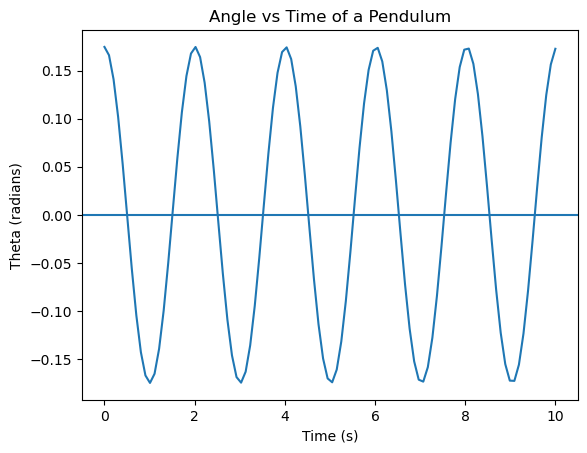

In [62]:
# Your code here
plt.plot(time_vals,theta_vals[0])
plt.axhline(y=0)
plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.title('Angle vs Time of a Pendulum')

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [63]:
# Your code here
print(T_numerical)

2.0202020202020203


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [64]:
# Your comment here
# The small angle approximation is somewhat close to the numerical calculation.

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [67]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [68]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [75]:
# Your code here
df = pd.read_csv('owid-covid-data.csv')

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [78]:
# Your code here
df_country = df.loc[df["location"] == "United States"]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [83]:
# Your code here
df_country = df_country[["date", "total_cases"]]
df_country = df_country.dropna()
days_since_start = range(len(df_country))
df_country['days_since_start'] = days_since_start

Print the first few rows of your `df_country` dataframe.

In [89]:
# Your code here
print(df_country.iloc[0:10])

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4
403456  2020-01-10          0.0                 5
403457  2020-01-11          0.0                 6
403458  2020-01-12          0.0                 7
403459  2020-01-13          0.0                 8
403460  2020-01-14          0.0                 9


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [93]:
# Your code here
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [94]:
# Your code here
def exponential_growth(t,C_0,r):
    # Returns number of cases at time t
    C_t = C_0*np.exp(r*t)
    return(C_t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [120]:
# Your code here
days = list(df_country['days_since_start'][0:31])
cases = list(df_country['total_cases'][0:31])

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [121]:
# Your code here
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [123]:
# Your code here
C0_fit = popt[0]
r_fit = popt[1]

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [125]:
# Your code here
print(C0_fit)
print(r_fit)

0.16890303612034968
0.13959940616249822


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [131]:
# Your code here
future_days = np.arange(0,61,1)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [132]:
# Your code here 
predicted_cases = exponential_growth(future_days,C0_fit,r_fit)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

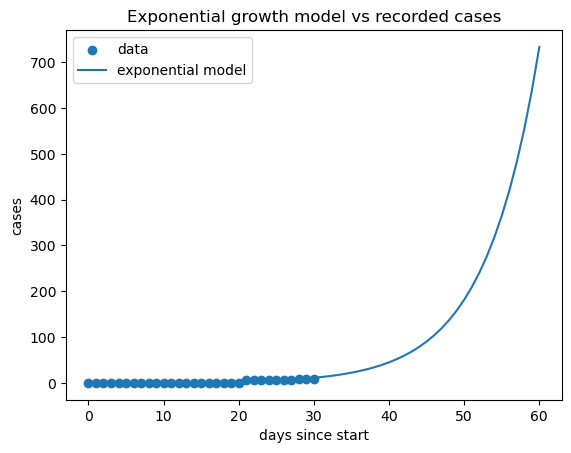

In [135]:
# Your code here
plt.scatter(days,cases,label='data')
plt.plot(future_days,predicted_cases,label='exponential model')
plt.xlabel('days since start')
plt.ylabel('cases')
plt.title('Exponential growth model vs recorded cases')
plt.legend()

How well does your exponential model fit the actual COVID-19 data? 

In [136]:
# Your comment here
# It fits the data quite well

Make another plot but this time to **90 days**.

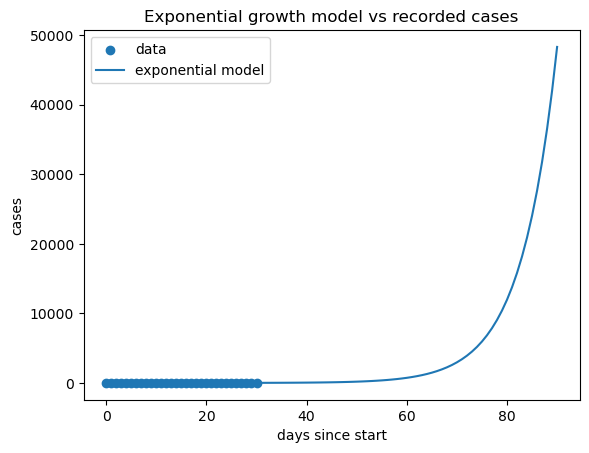

In [137]:
# Your code here
future_days = np.arange(0,91,1)
predicted_cases = exponential_growth(future_days,C0_fit,r_fit)
plt.scatter(days,cases,label='data')
plt.plot(future_days,predicted_cases,label='exponential model')
plt.xlabel('days since start')
plt.ylabel('cases')
plt.title('Exponential growth model vs recorded cases')
plt.legend()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [139]:
# Your code here
print(exponential_growth(87,C0_fit,r_fit),"cases")

31783.985988304106 cases


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

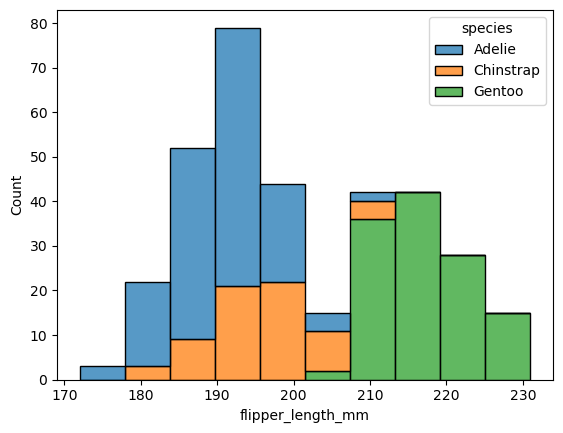

In [155]:
# Your code here
import seaborn as sns
penguins = sns.load_dataset('penguins')
sns.histplot(penguins, x="flipper_length_mm", hue="species", multiple="stack")

On it's own branch, submit this notebook to Gradescope! 